<a href="https://colab.research.google.com/github/koziychukal17-byte/A-B-Test-Analysis-Conversion-Metrics-Statistical-Significance/blob/main/Retail_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate/Pandas/

Mounted at /content/drive
/content/drive/MyDrive/Mate/Pandas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
events["Country Code"] = events["Country Code"].fillna("Unknown")
# Об'єднала events з products по Product ID, events з countries по Country Code через inner join
df = events.merge(products, left_on="Product ID", right_on="id") \
           .merge(countries, left_on="Country Code", right_on="alpha-3")
df.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,3/15/2015,4/18/2015,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


Об'єднала файл. Маємо таблицю з даними про продажі товарів для мережі мазинів, що мають онлайн та офлайн замовлення. Також працюєть в різних країнах. Дані зібрані за період з 2010 року по липень 2017 року.

В файлі містяться такі колонки:

* Order ID - індифікатор замовлення.
* Order Date - дата замовлення.
* Ship Date - дата отримання.
* Order Priority - пріоритетність замовлення.
* Country Code і alpha-3 - трьохзначний індифікатор регіону.
* Product ID і id	- індифікатор продукту.
* Sales Channel	- спосіб продажу товару.
* Units Sold	- кількість проданих одиниць.
* Unit Price - ціна за одиницю.
* Unit Cost	- витрати на одиницю товару.
* item_type	- назва продукту.
* name - назва країни.
* alpha-2 - код країни.
* region - назва частини світу.
* sub-region назва підрегіон.


In [ ]:
na_countries = countries.isna().sum() / countries.shape[0] * 100
na_events = events.isna().sum() / events.shape[0] * 100
na_products = products.isna().sum() / products.shape[0] * 100
print(na_countries)
print(na_events)
print(na_products)
df.isna().sum()

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      0.000000
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
id           0.0
item_type    0.0
dtype: float64


,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


Пропуски таблиці *countries* по 0,4% в тьох колонках можна просто видалити рядки з значеннями. Схоже на технічні помилки.

В *events* є пропуски в колонці Units Sold (0,16%), їх кількість не значна, тому потрібно їх видалити. Також середня по Units Sold 4980 одиниць і заповнення середньою спотворить наші показники.  Також схоже на технічні помилки. Наприклад, дані не внесено при формуванні замовлення.

Доля пропуски в колонці Country Code складає 6,16% - це сутева частина даних. Пропуски пропуную заповнити значеням  - Unknown (зробила це перед об'єднанням, що дані не пропали при inner join). Так як пропусків багато і це схоже на логічну послідовність, на мою думку пропуски виникли при прочитанні даних. Наприклад, не прочитався якийсь код країн.


In [ ]:
df = df.dropna()




Неправельний тип значень в таких колонках:
* Order ID,  Product ID, id - int64, а має бути object.
* Order Date, Ship Date - object має бути тип дати.
* Units Sold - float64, а має бути int64.



In [ ]:
df["Order ID"] = df["Order ID"].astype(object)
df["Product ID"] = df["Product ID"].astype(object)
df = df.drop("id", axis=1) # колонка id копія Product ID, тому видаляю її
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")


In [ ]:
df.duplicated().sum() # дублікатів немає

np.int64(0)

In [ ]:
df.describe()

,Order Date,Ship Date,Units Sold,Unit Price,Unit Cost
count,1246,1246,1246.000000,1246.000000,1246.000000
mean,2013-10-11 14:45:15.890850816,2013-11-05 11:46:07.897271296,4953.186998,264.203387,186.310088
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000
25%,2011-12-09 18:00:00,2011-12-31 12:00:00,2349.250000,81.730000,35.840000
50%,2013-10-14 00:00:00,2013-11-03 00:00:00,4980.000000,154.060000,97.440000
75%,2015-09-01 12:00:00,2015-10-07 18:00:00,7477.000000,433.372500,263.330000
max,2017-07-22 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000
std,NaN,NaN,2915.825155,216.592937,175.503652


In [ ]:
Q1 = df["Units Sold"].quantile(0.25)
Q3 = df["Units Sold"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliersUS = df[(df["Units Sold"] < lower) | (df["Units Sold"] > upper)]

print(outliersUS)

Q1 = df["Unit Price"].quantile(0.25)
Q3 = df["Unit Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliersUP = df[(df["Unit Price"] < lower) | (df["Unit Price"] > upper)]

print(outliersUP)

Q1 = df["Unit Cost"].quantile(0.25)
Q3 = df["Unit Cost"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliersUC = df[(df["Unit Cost"] < lower) | (df["Unit Cost"] > upper)]

print(outliersUC)

Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost, item_type, name, alpha-2, alpha-3, region, sub-region]
Index: []
Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost, item_type, name, alpha-2, alpha-3, region, sub-region]
Index: []
Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost, item_type, name, alpha-2, alpha-3, region, sub-region]
Index: []


В числових колонках аномалій немає.


In [ ]:
df = df.drop("alpha-2", axis=1)
df = df.drop("alpha-3", axis=1)


In [ ]:
df = df.rename(columns={"name":"country"})


# Data analysis and visualization.

In [ ]:
#загальна кількість замовлень
total_units_sold = df["Units Sold"].sum().astype(int)
#порахувала дохід за замовленя та загальний дохід
df["order_revenue"]= df["Units Sold"] * df["Unit Price"]
total_revenue = df["order_revenue"].sum().round(2)
#загальна кількість охоплених країн
number_of_countries =  df["country"].nunique()
#загальна кількість категорій товару
number_of_category =  df["item_type"].nunique()
#порахувала витрати за замовленя та загальні витрати
df["order_cost"] = df["Units Sold"] * df["Unit Cost"]
total_cost = df["order_cost"].sum().round(2)
#порахувала прибуток за замовленя та загальний прибуток
df["order_profit"] = df["order_revenue"] - df["order_cost"]
total_profit = df["order_profit"].sum().round(2)
df["margin"] = df["order_profit"] / df["order_revenue"] * 100
avg_delivery_time = np.mean(df["delivery_time"]).astype(int)
print(f"Total sold: {total_units_sold: ,}")
print(f"Total revenue: {total_revenue: ,} $")
print(f"Total cost: {total_cost: ,}$")
print(f"Total profit: {total_profit: ,}$")
print(f"Number of country: {number_of_countries}")
print(f"Number of category: {number_of_category}")
print(f"Averadge delivery time: {avg_delivery_time}")



Total sold:  6,171,671
Total revenue:  1,598,983,761.26 $
Total cost:  1,125,274,726.2$
Total profit:  473,709,035.06$
Number of country: 45
Number of category: 12
Averadge delivery time: 24


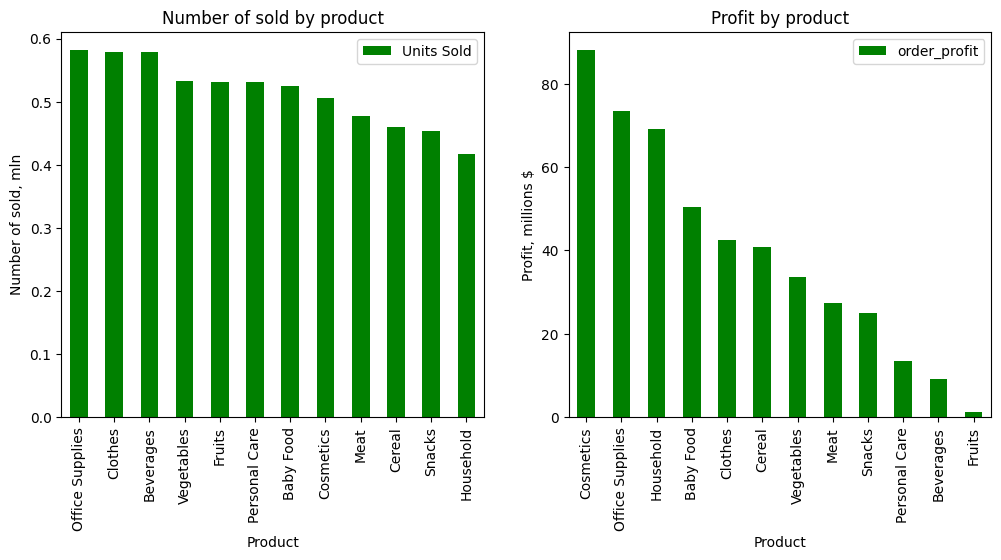

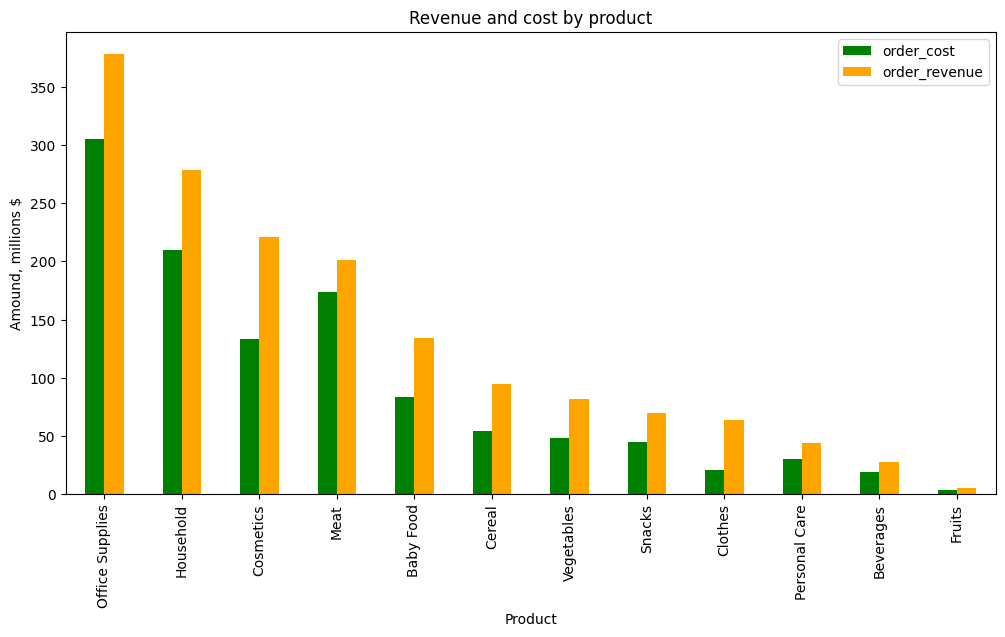

          item_type     margin
3           Clothes  67.203514
2            Cereal  43.067574
11       Vegetables  40.977541
4         Cosmetics  39.768984
0         Baby Food  37.550924
10           Snacks  36.138419
1         Beverages  33.003161
9     Personal Care  30.661936
5            Fruits  25.830654
6         Household  24.799856
8   Office Supplies  19.386987
7              Meat  13.558036


In [ ]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
numb_of_product = df.groupby("item_type")["Units Sold"].sum().sort_values(ascending=False).reset_index()
numb_of_product["Units Sold"] = numb_of_product["Units Sold"] / 1000_000
numb_of_product.head(12).plot(kind="bar", x="item_type", y="Units Sold", color="green", ax=ax[0])
ax[0].set_title("Number of sold by product")
ax[0].set_xlabel("Product")
ax[0].set_ylabel("Number of sold, mln")

item_type_table_prof = df.groupby("item_type")["order_profit"].sum().sort_values(ascending=False).reset_index()
item_type_table_prof["order_profit"] = item_type_table_prof["order_profit"] / 1000000
item_type_table_prof.head(12).plot(kind="bar", x="item_type", y="order_profit", color="green", ax=ax[1])
ax[1].set_title("Profit by product")
ax[1].set_xlabel("Product")
ax[1].set_ylabel("Profit, millions $")
plt.show()

item_type_table = pd.pivot_table(df, values=["order_cost", "order_revenue"], index="item_type", aggfunc="sum")
item_type_table_sort = item_type_table.sort_values(by="order_revenue", ascending=False) / 1000000
item_type_table_sort.plot(kind="bar", figsize=(12, 6), color=["green", "orange", "blue"])
plt.title("Revenue and cost by product")
plt.xlabel("Product")
plt.ylabel("Amound, millions $")
plt.show()

avaredge_margin = df.groupby("item_type")["margin"].mean().reset_index()
avaredge_margin_s = avaredge_margin.sort_values("margin", ascending=False)
print(avaredge_margin_s)




Найпопулярнішими категоріями є Office Supplies, Clothes, Beverages.

Найприбутковішими є категорії: Cosmetics, Office Supplies, Household, ці графіки дають розуміння, що популярність категорії, не означає прибутковість і на прибуткових товарах вища ціна чи маржа.

По доходу перші три категорії такі з як по прибутковості, лиш в іншій послідовності. Найменш прибутковіші такі ж як найменш дохідні, а саме "Personal Care", "Beverages", "Fruits".

Категорія Beverages входить до найпопулярніших за кількістю продажів, але водночас є однією з найменш прибуткових. Причиною є невисока ціна товарів цієї категорії. Beverages та Fruits продаються у великій кількості, але ціна їх не велика, тому потрібно переглянути цінову політику на цих категоріях або не вкладати ресурси в їх просування та зоосередитись не прибутковіших категіріях.


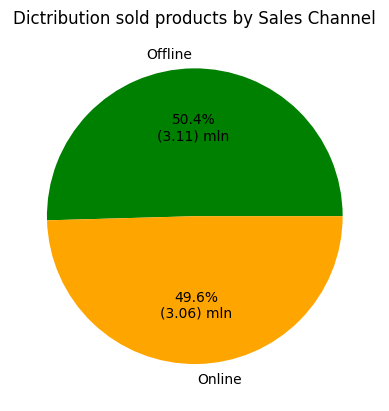

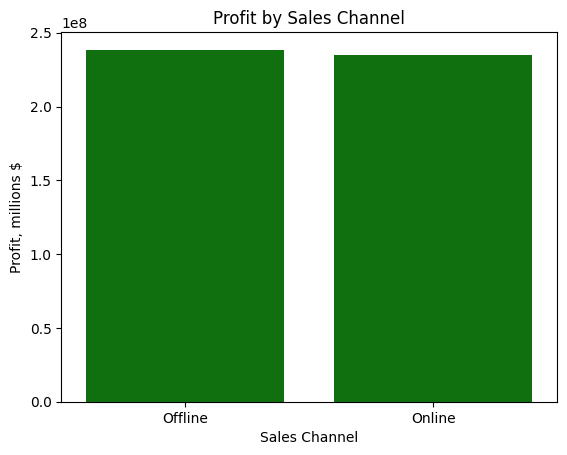

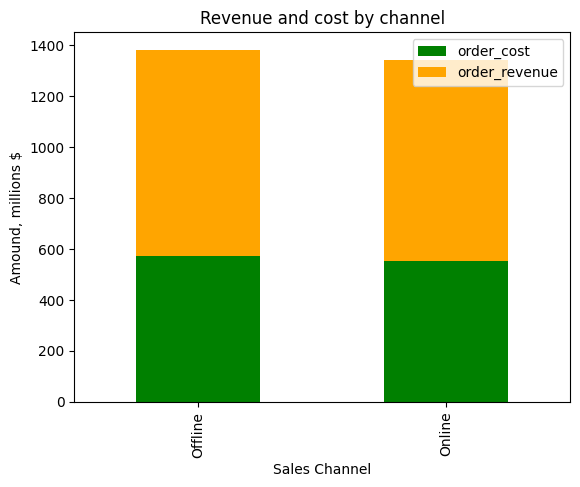

In [ ]:
df["Sales Channel"] = df["Sales Channel"].str.replace("o", "O")
channel_table = pd.pivot_table(df, values=["Units Sold", "order_profit"], index="Sales Channel", aggfunc="sum").reset_index()
channel_table.iloc[:, 1] = channel_table.iloc[:, 1] / 1000_000

values0 = channel_table["Units Sold"]
def my_autopct0(pct0):
    total0 = sum(values0)
    value0 = pct0 * total0 / 100
    return f'{pct0:.1f}%\n({value0:.2f}) mln'
plt.pie(channel_table["Units Sold"], labels=channel_table["Sales Channel"], autopct=my_autopct0, colors=["green", "orange"])
plt.title("Dictribution sold products by Sales Channel")
plt.show()

sns.barplot(channel_table, x="Sales Channel", y="order_profit", color="green")
plt.title("Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit, millions $")
plt.show()

channel_table_rc = pd.pivot_table(df, values=["order_cost", "order_revenue"], index="Sales Channel", aggfunc="sum") / 1000000
channel_table_rc_sort = channel_table_rc.sort_values(by="order_revenue", ascending=False)
channel_table_rc.head(10).plot(kind="bar", stacked=True, color=["green", "orange"])
plt.title("Revenue and cost by channel")
plt.xlabel("Sales Channel")
plt.ylabel("Amound, millions $")
plt.show()


Продажі онлайн і офлайн мають аномально рівні долі по кількості. Це ж саме прослідковується по прибутку, доході та витратах, заявляється питання, чому так. Офлайн канал повинен переважати по витратах, оскільки на утримання торгових точок (оренда, обслуговування, комуналка та інші питання) мали б йти більше витрат.

Бізнесу потрібно переглянути достовірність витрат онлайн каналу, якщо ж вони достовірні, то потрібно переглянути витрати цього каналу.

   region  Units Sold  order_cost  order_profit  order_revenue
0    Asia        0.41       68.18         25.15          93.33
1  Europe        5.76     1057.10        448.56        1505.65



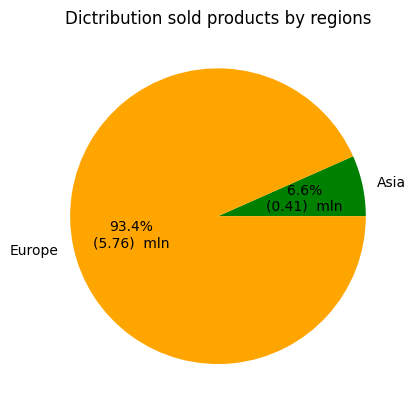

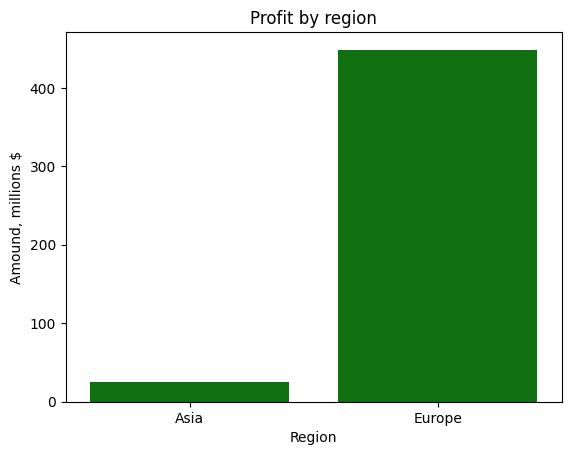

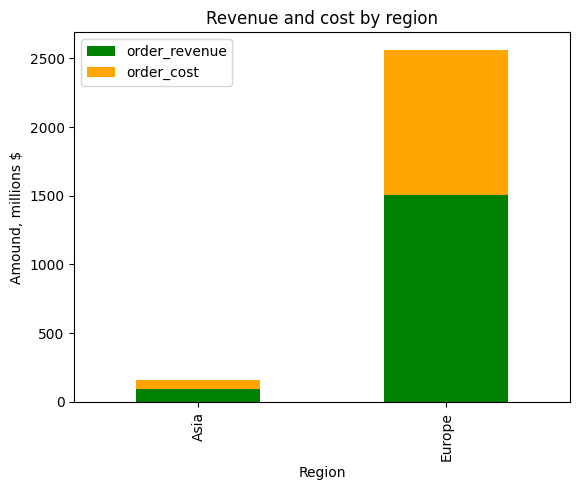

region
Asia       3
Europe    42
Name: country, dtype: int64


In [ ]:
region_table = (pd.pivot_table(df, index="region", values=["Units Sold", "order_revenue", "order_cost", "order_profit"], aggfunc="sum") / 1000_000).round(2).reset_index()
print(f"{region_table}\n")

values = region_table["Units Sold"]
def my_autopct(pct):
    total = sum(values)
    value = pct * total / 100
    return f'{pct:.1f}%\n({value:.2f})  mln'
plt.pie(region_table["Units Sold"], labels=region_table["region"], autopct=my_autopct, colors=["green", "orange"])
plt.title("Dictribution sold products by regions")
plt.show()

sns.barplot(region_table, x="region", y="order_profit", color="green")
plt.title("Profit by region")
plt.xlabel("Region")
plt.ylabel("Amound, millions $")
plt.show()

region_table.plot(kind="bar", x="region", y=["order_revenue", "order_cost"], stacked=True, color=["green", "orange"])
plt.title("Revenue and cost by region")
plt.xlabel("Region")
plt.ylabel("Amound, millions $")
plt.show()

countries_by_region = df.groupby("region")["country"].nunique()
print(countries_by_region)


З аналізу по регіону випливає, що наш основний ринок - це Європа(93,4% кількості одиниць товарів йде саме з цього регіону).

Тому логічним є, що прибутки надходять здебільшого з цього регіону. Тому при запуску маркетингової стратегії потрібно враховувати саме це.

В Європі 42 країни і 3 в Азії. Потрібно дізнатись в бізнесу чи Азія лише тестовий проект і чи планується розширення ринку.

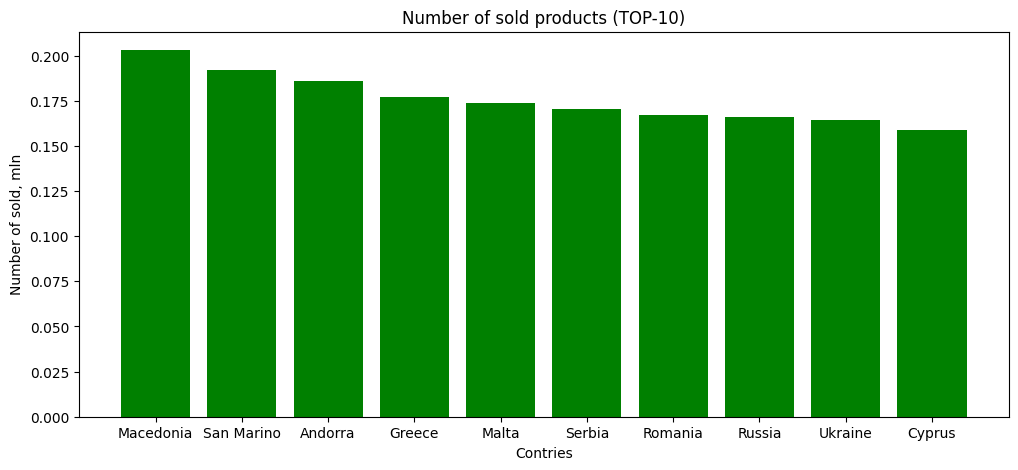

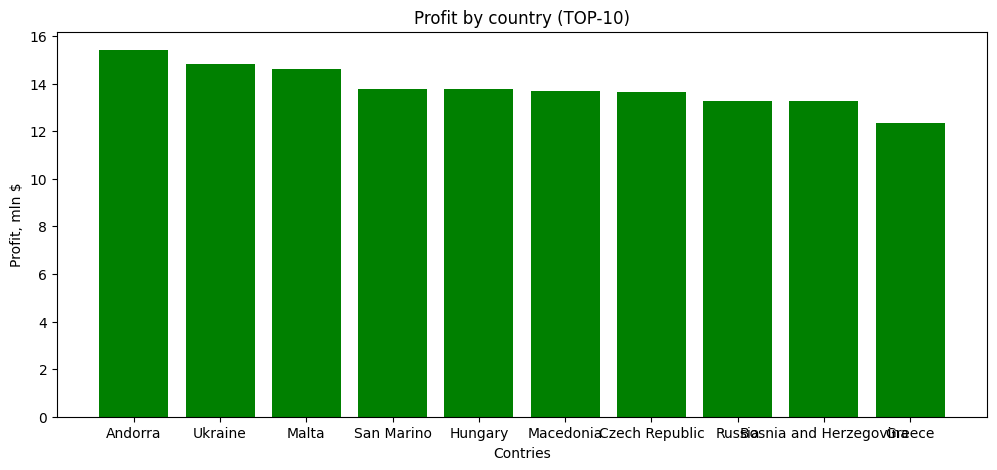

<Figure size 800x500 with 0 Axes>

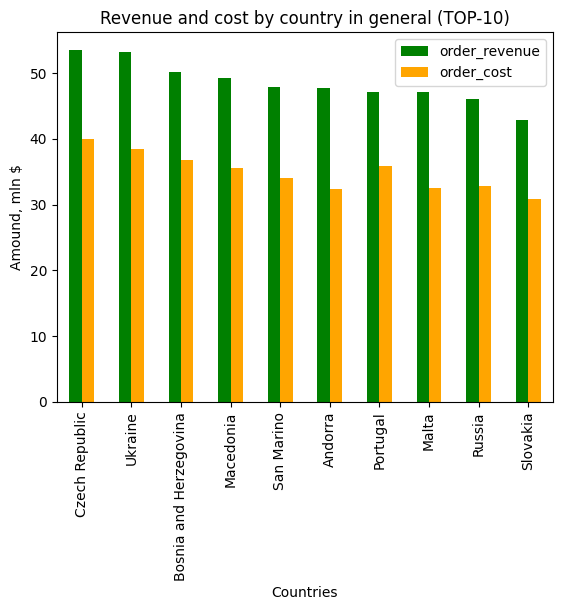

In [ ]:
country_table = pd.pivot_table(df, index=["region", "country"], values=["Units Sold", "order_revenue", "order_cost", "order_profit"], aggfunc="sum").reset_index()
country_table.iloc[:, 2:] = country_table.iloc[:, 2:] / 1000_000
country_table_sorted = country_table.sort_values(by="Units Sold", ascending=False)
country_table_sorted = country_table_sorted[ :10]
#кількості проданих одиниць
plt.figure(figsize=(12,5))

plt.bar(country_table_sorted["country"], country_table_sorted["Units Sold"], color="green")
plt.title("Number of sold products (TOP-10)")
plt.xlabel("Contries")
plt.ylabel("Number of sold, mln")

plt.show()

plt.figure(figsize=(12,5))

country_table_sorted_p = country_table.sort_values(by="order_profit", ascending=False)
country_table_sorted_p = country_table_sorted_p[ :10]
#порівняння прибитку
plt.bar(country_table_sorted_p["country"], country_table_sorted_p["order_profit"], color="green")
plt.title("Profit by country (TOP-10)")
plt.xlabel("Contries")
plt.ylabel("Profit, mln $")

plt.show()

country_table_sorted_r = country_table.sort_values(by="order_revenue", ascending=False)

plt.figure(figsize=(8,5))

country_table_sorted_r.head(10).plot(kind="bar", x="country", y=["order_revenue", "order_cost"], color=["green", "orange"])
plt.title("Revenue and cost by country in general (TOP-10)")
plt.xlabel("Countries")
plt.ylabel("Amound, mln $")
plt.show()


При порівнянні країн регіонів Азії і Європи по кількості проданих одиниць випливає, що в країнах Європи продається більша кількість одиниць ніж в Азії. Тільки 1 країна Азії потрапила в ТОП-10.

Постає питання: чи застосовуються окремі маркетингові кампанії для регіонів Азії та Європи, адже, якщо кампанії однакові, то стратегія не враховує відміності в культурі та поведінці аудиторії.

В ТОП по прибутку країни Азії не потрапляють. Відсутність азійських країн у ТОП-10 за прибутком може свідчити про недостатню локалізацію маркетингових кампаній або різницю в поведінці споживачів. Є доцільним тестування окремих маркетингових стратегій для різних регіонів.

Країни з високим прибутком та стабільним попитом можуть розглядатися як ключові ринки для подальшого розширення асортименту та збільшення маркетингового бюджету.

Високі доходи не завжди свідчать про високу прибутковість. Наприклад, Чеська республіка та Боснія і Герцеґовина входять в ТОП-3 по доходу, а по прибутку просідають, тому потрібно переглянути витрати в цих країнах та можливість їх оптимізувати.

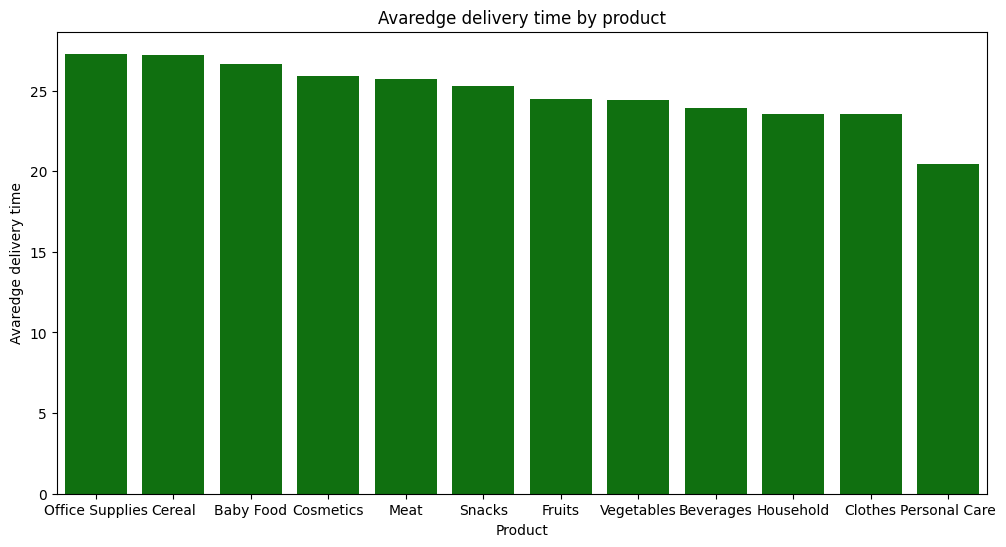

<Figure size 1200x600 with 0 Axes>

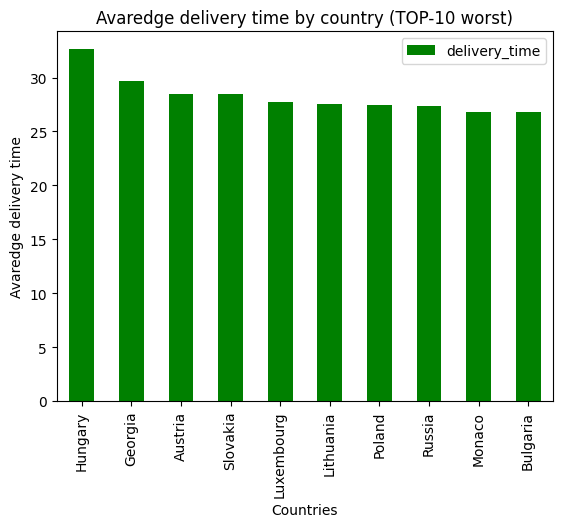

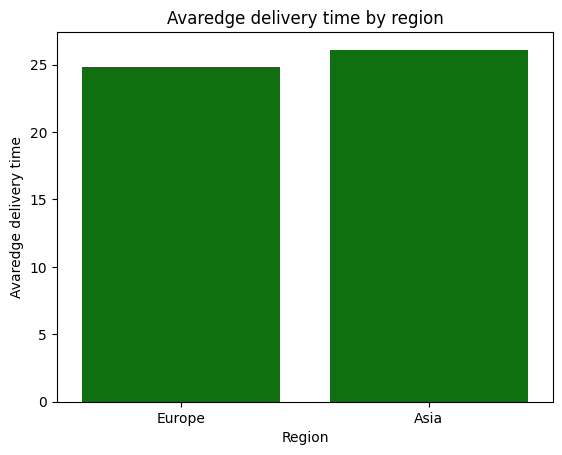

In [ ]:
df["delivery_time"] = (df["Ship Date"] - df["Order Date"]).dt.days.astype(int)
delivery_time_table = pd.pivot_table(df, index="item_type", values="delivery_time", aggfunc="mean").reset_index()
delivery_time_table_sorted = delivery_time_table.sort_values(by="delivery_time", ascending=False)
#print(delivery_time_table_sorted)

plt.figure(figsize=(12, 6))
sns.barplot(data=delivery_time_table_sorted, x="item_type", y="delivery_time", color="green", errorbar=("ci", False))
plt.title("Avaredge delivery time by product")
plt.xlabel("Product")
plt.ylabel("Avaredge delivery time")
plt.show()

delivery_time_countries = pd.pivot_table(df, index="country", values="delivery_time", aggfunc="mean").reset_index()
delivery_time_countries_sorted = delivery_time_countries.sort_values(by="delivery_time", ascending=False)

plt.figure(figsize=(12, 6))
delivery_time_countries_sorted.head(10).plot(kind="bar", x="country", y="delivery_time", color="green")
plt.title("Avaredge delivery time by country (TOP-10 worst)")
plt.xlabel("Countries")
plt.ylabel("Avaredge delivery time")
plt.show()

sns.barplot(data=df, x="region", y="delivery_time", color="green", errorbar=("ci", False))
plt.title("Avaredge delivery time by region")
plt.xlabel("Region")
plt.ylabel("Avaredge delivery time")

plt.show()



Середній інтервал часу між замовлення та відвантаженням варіюється між 27 днів до 20. Найдовше Office Supplies 27 днів, найшвидше Personal Care 20 днів.

Цікавим є те, що м'ясо, фрукти та овочі доставляються 24-25 в середньому. Потрібно переглянути логістику, оскільки таке тривале транспортування може ставити під загрозу якість продуктів та їхню безпеку.

Також в цікому доставка в середньому триває 24 дні. Найдовше доставляється до Угорщини, Грузії та Австрії, але розрив не великий в цілому середння доставка від 32 до 18 днів. Тому потрібно переглянути логістику, оскільки компанія може втрачати покупців в майбутньому.

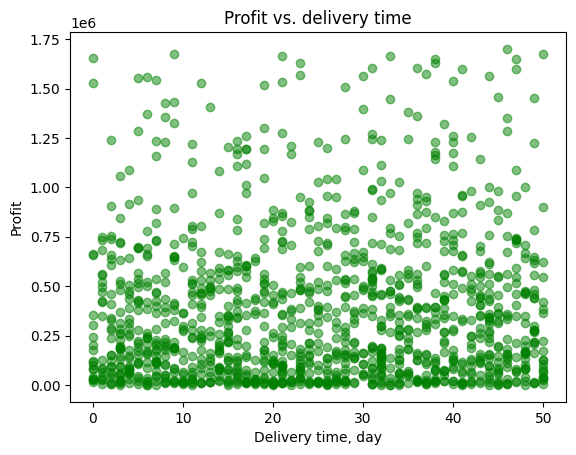

In [ ]:
plt.scatter(df["delivery_time"], df["order_profit"], color="green", alpha=0.5)
plt.title("Profit vs. delivery time")
plt.xlabel("Delivery time, day")
plt.ylabel("Profit")

plt.show()

Після аналізу діаграми розсіювання залежності між прибутком та доставкою не виявлено. Корелюючими є інші фактори.

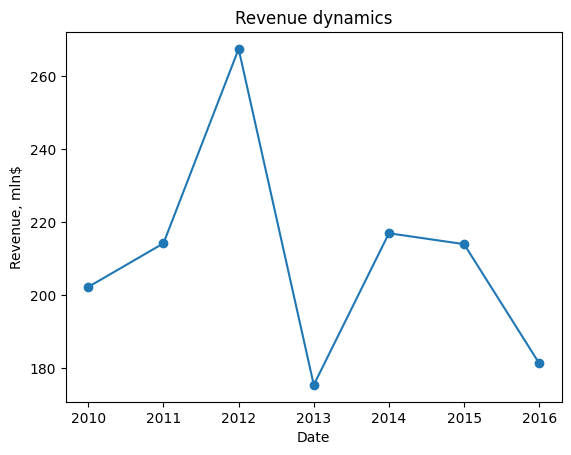

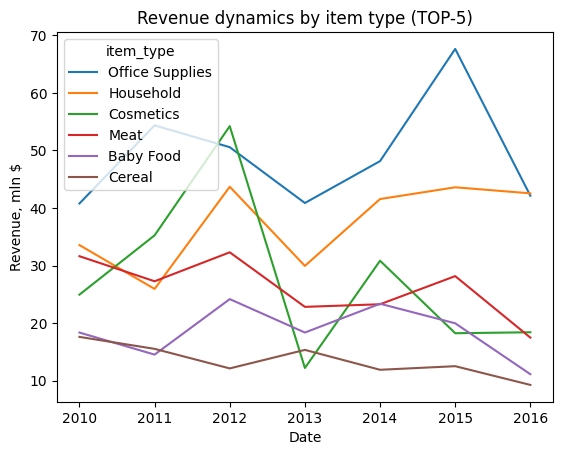

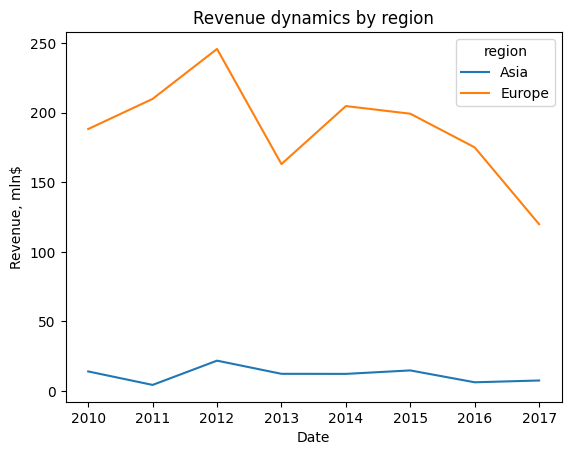

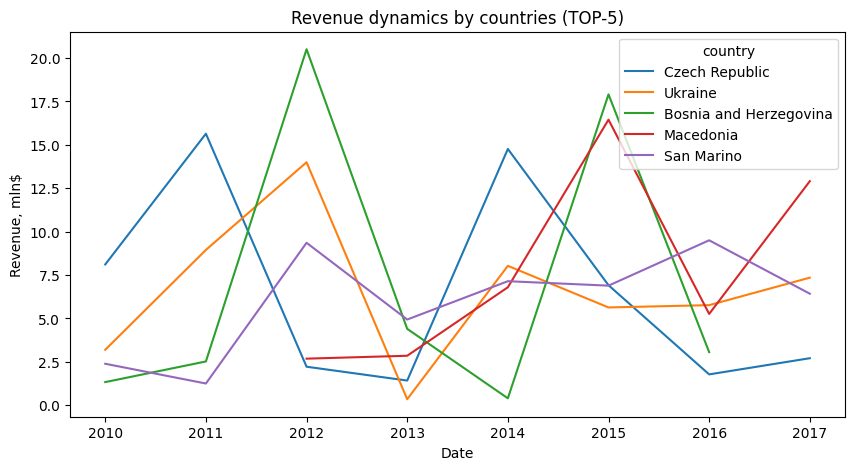

In [ ]:
from matplotlib import markers
max_date = df['Order Date'].max()
df["order_year"] = df['Order Date'].dt.to_period("Y").astype(str)
revenue_dynemics = df.groupby("order_year")["order_revenue"].sum().reset_index()
revenue_dynemics["order_revenue"] = revenue_dynemics["order_revenue"] / 1000_000
revenue_dynemics = revenue_dynemics[:7] #2017 не повний рік, тому в аналіз не беру

plt.plot(revenue_dynemics["order_year"], revenue_dynemics["order_revenue"], marker="o")
plt.title("Revenue dynamics")
plt.xlabel("Date")
plt.ylabel("Revenue, mln$")

plt.show()

revenue_dynemics_by_item = pd.pivot_table(df, index="order_year", values="order_revenue", columns="item_type", aggfunc="sum").reset_index()
revenue_dynemics_by_item = revenue_dynemics_by_item[:7]
revenue_dynemics_by_item.iloc[:, 1:] = revenue_dynemics_by_item.iloc[:, 1:] / 1_000_000

revenue_dynemics_by_item.loc[:, ["order_year", "Office Supplies", "Household", "Cosmetics", "Meat", "Baby Food", "Cereal"]].plot(x="order_year")
plt.title("Revenue dynamics by item type (TOP-5)")
plt.xlabel("Date")
plt.ylabel("Revenue, mln $")

plt.show()


region_revenue_dyn = pd.pivot_table(df, index="order_year", values="order_revenue", columns="region", aggfunc="sum").reset_index()
region_revenue_dyn.iloc[:, 1:] = (region_revenue_dyn.iloc[:, 1:] / 1000_000).round(2)

region_revenue_dyn.plot(x="order_year")
plt.title("Revenue dynamics by region")
plt.xlabel("Date")
plt.ylabel("Revenue, mln$")

plt.show()

country_rev_dyn = pd.pivot_table(df, index="order_year", values="order_revenue", columns="country", aggfunc="sum").reset_index()
country_rev_dyn_top = country_rev_dyn.loc[:, ["order_year", 'Czech Republic', 'Ukraine', 'Bosnia and Herzegovina', 'Macedonia', 'San Marino']]
country_rev_dyn_top.iloc[:, 1:] = country_rev_dyn_top.iloc[:, 1:] / 1000_000

country_rev_dyn_top.plot(x="order_year", figsize=(10,5))
plt.title("Revenue dynamics by countries (TOP-5)")
plt.xlabel("Date")
plt.ylabel("Revenue, mln$")

plt.show()


Динаміка продажів в часі показує, що 2012 рік був найбільш дохідним. Потрібно вичначити чому, чи це ріст економіки, чи це ріст клієнтської активності. Кількість проданих товарів теж в цей рік є найвища. Потрібні дані для глибшого аналізу. Наприклад, проаналізувати маркетинговіх показники у цей рік.
А 2013 та 2016 були роками провалу і по доходу і по проданим одиницям. Потрібно теж глибше проаналізувати причини для уникнення їх в майбутньому.

Аналіз по категоріях дає такий результат:
1. Office Supplies (найдохідніша категорія) розкид даних від 40 до 55 мільйонів доларів, окрім 2015, тут прослідковується пік продажів - 67 мільйонів. В 2015 інші категорії показують стадільність, лише ця має значний ріст. Можливо це вдала реклама кампанія чи вигідні знижки. Потрібно проаналізувати маркетингові показники цього року і категорії, для розуміння причини.
2. Cosmetics і Household мають тенденції наближенні до загальних, пік в 2012 і падіння в 2013.
3. Meat, Baby Food і Cereal мають стадільні коливання протягом аналізованого періоду з падінням в 2016 році.

Аналіз регіонів дав такі регультати: Азія показує стабільність з незначним піком в 2012, Європа має пік в 2012 (майже 250 мільйонів доларів) та падіння в 2013 та 2016.


На графіку динаміки доходів по країнах видно, що в різні роки країни демонструють нестабільні показники доходу, що може свідчити про вплив зовнішніх економічних факторів, сезонності попиту та ефективності маркетингових кампаній.

Найбільш різкі коливання спостерігаються у Боснії і Герцеґовина, де у 2012 та 2015 роках доходи значно зросли, проте в інші періоди показники суттєво знижувались. Це може свідчити про залежність продажів від окремих кампаній або нестабільного попиту.

Чешська республіка показує відносно високі доходи у 2011 та 2014 роках, після чого спостерігається поступове зниження показників.

Україна показує пік доходу в 2012 та спад в 2013, проте з 2014 динаміка більш плавна, що може свідчити про стабільний попит та більш рівномірну поведінку споживачів. Дохід коливається від 5 до 7,5 мільйонів доларів. Україна також займає 2 місце по прибутку в цілому, тому компанія має звернути увагу на цей ринок для залучення додаткових інвестицій.

Македонія демонструє тенденцію до зростання доходів у період 2014–2017 років (окрім 2016), що може бути пов’язано з покращенням маркетингової стратегії, розширенням клієнтської бази або еконімічних показників конкретної країни.

Сан Маріно має найбільш стабільні показники серед ТОП-5 країн по доходу без різких коливань. Це може свідчити про стабільну аудиторію та передбачуваний рівень продажів.

Загалом аналіз динаміки доходів показує, що різні країни мають різну динаміку доходу, тому використання однакових маркетингових стратегій для всіх регіонів може бути недостатньо ефективним. Доцільним є адаптування рекламних кампаній та підходів до продажів відповідно до особливостей кожного регіону.

In [ ]:
sp_contry = country_table_sorted["country"]

list(sp_contry.head())

['Macedonia', 'San Marino', 'Andorra', 'Greece', 'Malta']

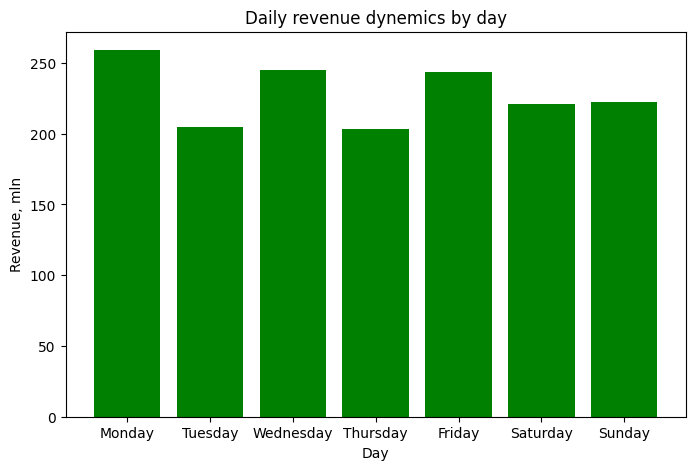

Text(0, 0.5, 'Revenue, mln')

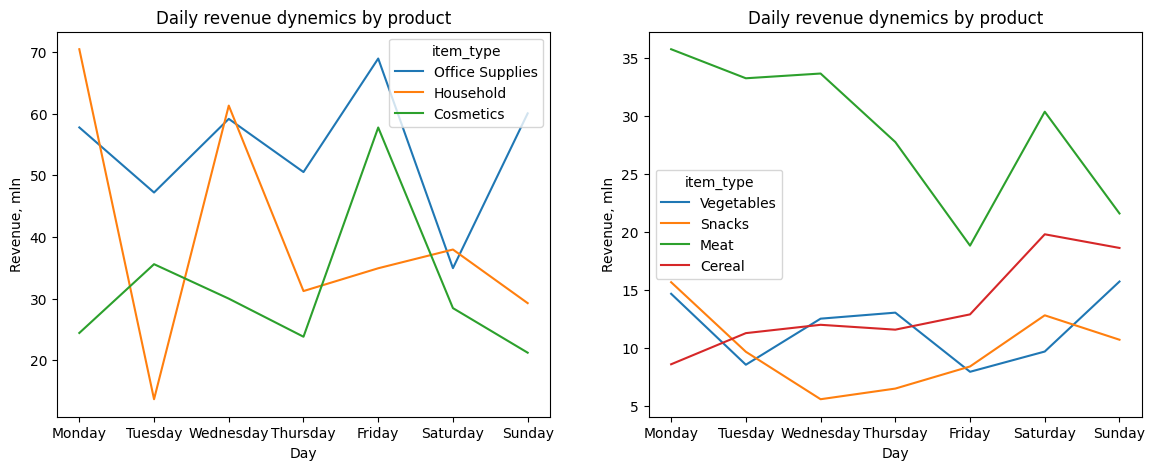

In [ ]:
days_order = [ "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["order_day"] = df["Order Date"].dt.day_name()
day_trends = df.groupby("order_day")["order_revenue"].sum().reset_index()
day_trends.iloc[:, 1:] = (day_trends.iloc[:, 1:] / 1000_000).round(2)
day_trends["order_day"] = pd.Categorical(day_trends["order_day"], categories=days_order, ordered=True)
day_trends = day_trends.sort_values("order_day")

plt.figure(figsize=(8,5))
plt.bar(day_trends["order_day"], day_trends["order_revenue"], color="green")
plt.title("Daily revenue dynemics by day")
plt.xlabel("Day")
plt.ylabel("Revenue, mln")

plt.show()

day_trends_tab = pd.pivot_table(df, index="order_day", values="order_revenue", columns="item_type", aggfunc="sum").reset_index()
day_trends_tab["order_day"] = pd.Categorical(day_trends_tab["order_day"], categories=days_order, ordered=True)
day_trends_tab = day_trends_tab.sort_values("order_day")
day_trends_tab.iloc[:, 1:] = (day_trends_tab.iloc[:, 1:] / 1000_000).round(2)

fig, ax = plt.subplots(1,2, figsize=(14,5))

day_trends_tab.loc[:, ["order_day", "Office Supplies", "Household", "Cosmetics"]].plot(x="order_day", ax=ax[0])
ax[0].set_title("Daily revenue dynemics by product")
ax[0].set_xlabel("Day")
ax[0].set_ylabel("Revenue, mln")

day_trends_tab.loc[:, ["order_day", "Vegetables", "Snacks", "Meat", "Cereal"]].plot(x="order_day", ax=ax[1])
ax[1].set_title("Daily revenue dynemics by product")
ax[1].set_xlabel("Day")
ax[1].set_ylabel("Revenue, mln")



Якщо дивитись в цілому по доходу по всім категоріям найдохідніший день - понеділок. Далі ще в середу і п'ятницю продажі кращі.

Помітила тенденцію, що "Office Supplies", "Household" та "Meat" в понеділок, середу і п'ятницю продаються кращеу. "Cosmetics" - пік в середу. "Vegetables" s "Snacks" зростання продажів у понеділок і суботу. "Cereal" - пік в суботу. По цим категоріям пропоную запускати рекламну кампанію в дні піків для покращення продажів, оскільки прослідковується сезоність.

Прибрала категорії, де сезоність не прослідковується взагалі.

#The key takeaways this analysis:
* Найприбутковішими є категорії: Cosmetics, Office Supplies, Household, тому компанії потрібно тримати фокус на просування цим категорій товарів.

* Найменш прибутковіші та найменш дохідні категорії це: "Personal Care", "Beverages", "Fruits". Beverages та Fruits продаються у великій кількості, але ціна їх не висока, тому потрібно переглянути цінову політику по цих категоріях або не вкладати ресурси в їх просування та зоосередитись не прибутковіших категіріях.

* Показники в розрізі каналу продажу (онлайн і офлайн) майже на одному рівні, що кількість проданих одиниць, що прибутки, що доходи з витратами. Тому потрібно перевірити достовірність відображення каналів продажу та провести аналіз витратних статтів, оскільки структура витрат офлайн складніша та їх величина повинна перевищувати онлайн витрати.

* З аналізу по регіону випливає, що наш основний ринок - це Європа(93,4% проданих одиниць). Також аналіз динаміки доходів показує, що різні країни мають різну динаміку доходу, тому використання однакових маркетингових стратегій для всіх регіонів може бути недостатньо ефективним. Доцільним є адаптування рекламних кампаній та підходів до продажів відповідно до особливостей кожного регіону.

* Країни з високим прибутком та стабільним попитом можуть розглядатися як ключові ринки для подальшого розширення асортименту та збільшення маркетингового бюджету. А саме: Андора, Україна, Мальта, Сан Маріно, Угорщина.

* Доставка продукції в середньому триває 24 дні та варіюється від 18 до 32 днів. Тому потрібно переглянути логістику, оскільки компанія може втрачати покупців в майбутньому.

* Прямої залежності між прибутком та доставкою не виявлено. Але в нас немає інформації про наступні замовлення поточних клієнтів (відсутній id клієнта), тому для того щоб перевірити наступні замовлення та спростувати гіпотезу по майбутні втрати потрібні дані для глибшого аналізу.

* Динаміка продажів в часі показує, що 2012 рік був найбільш дохідним та мав найбільшу кількість проданих товарів. Потрібно вичначити чому, чи це ріст економіки, чи це ріст клієнтської активності. Потрібні проаналізувати маркетинговіх показники у цей рік. А 2013 та 2016 були роками провалу по доходу і по проданим одиницям. Потрібно теж глибше проаналізувати причини для уникнення їх в майбутньому.

* Цілому по доходу найдохідніший день - понеділок. Далі кожна кагегорія продукту має власну сезоність, тому пропоную запускати рекламну кампанію в дні піків для покращення продажів.